# Task 2: Exploratory Data Analysis (EDA)
### SaiKet Systems — Data Science Internship
**Intern:** Omokhoa Oshose Tosayoname | **ID:** SKS/A2/C115874  
**Project:** Customer Churn Analysis and Prediction  
**Date:** April 2026

---

## Objective
Calculate and visually represent the overall churn rate. Explore customer distributions
by gender, partner status, dependent status, tenure, contract type, and payment method.
Identify key patterns that differentiate churned customers from retained ones.


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'axes.labelsize': 10})

# Colour palette — consistent throughout
CLR_RETAIN = '#2196F3'   # blue  → not churned
CLR_CHURN  = '#F44336'   # red   → churned
PALETTE    = [CLR_RETAIN, CLR_CHURN]

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Load raw dataset (pre-encoding) for human-readable categorical plots
df = pd.read_csv('telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])
df.drop(columns=['customerID'], inplace=True)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)


Dataset loaded: 7043 rows × 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Overall Churn Rate
The churn rate is the percentage of customers who left the service within the observation period.
It is the primary KPI this project aims to predict and reduce.


In [3]:
churn_counts = df['Churn'].value_counts()
churn_rate   = (churn_counts['Yes'] / len(df)) * 100

print(f"Total customers   : {len(df):,}")
print(f"Churned           : {churn_counts['Yes']:,} ({churn_rate:.2f}%)")
print(f"Retained          : {churn_counts['No']:,} ({100-churn_rate:.2f}%)")


Total customers   : 7,043
Churned           : 1,869 (26.54%)
Retained          : 5,174 (73.46%)


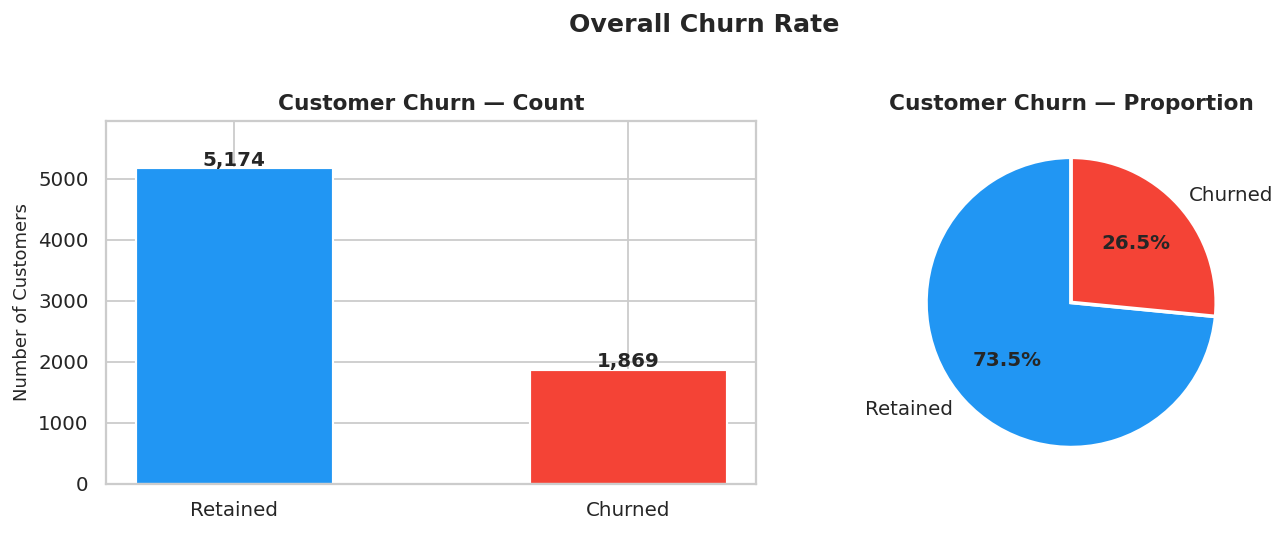

Key insight: ~26.5% churn rate indicates a class imbalance that models must account for.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(['Retained', 'Churned'], churn_counts[['No','Yes']].values,
                   color=PALETTE, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Customer Churn — Count')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts[['No','Yes']].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts[['No','Yes']].values,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    colors=PALETTE,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Customer Churn — Proportion')

plt.suptitle('Overall Churn Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_01_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Key insight: ~{churn_rate:.1f}% churn rate indicates a class imbalance that models must account for.")


## 3. Customer Distribution by Demographics
We examine churn patterns across gender, partner status, dependent status, and senior citizen status.


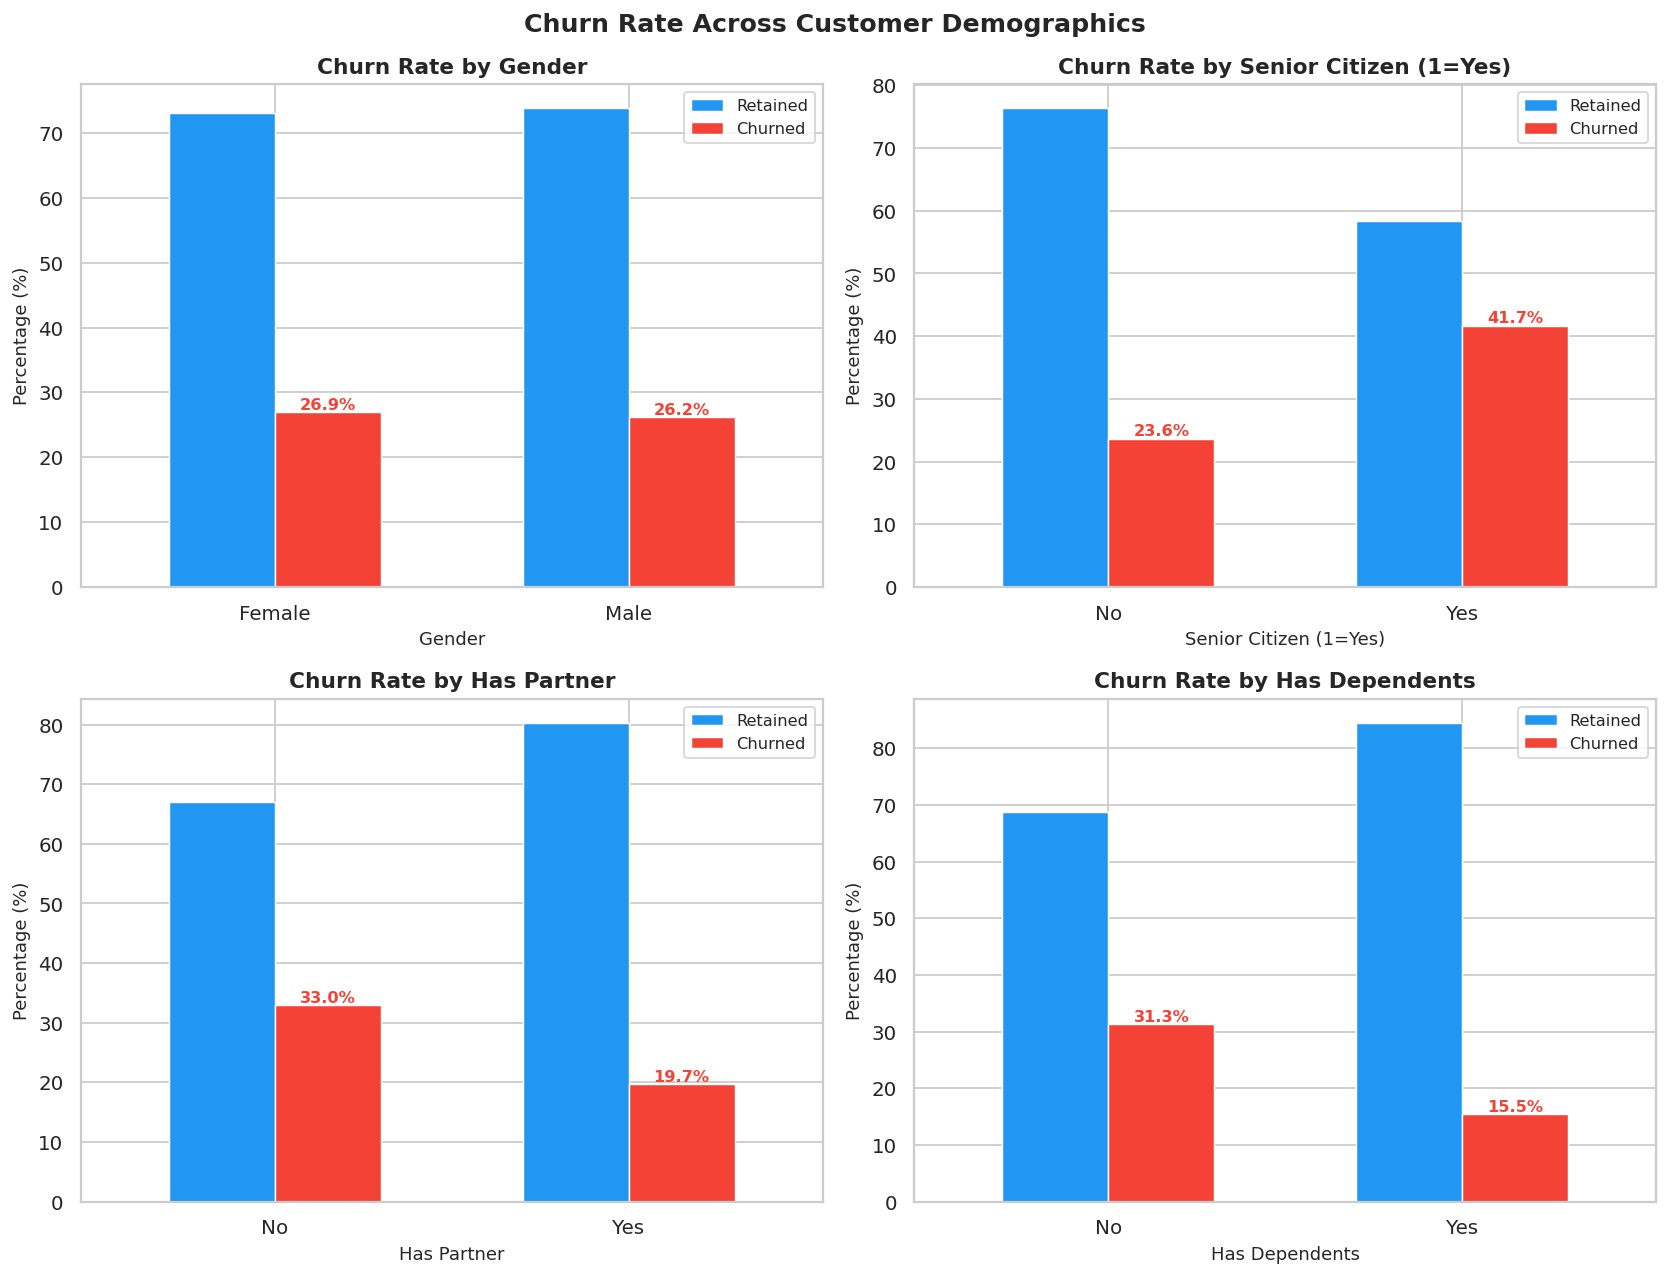

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

demo_cols = {
    'gender'        : 'Gender',
    'SeniorCitizen' : 'Senior Citizen (1=Yes)',
    'Partner'       : 'Has Partner',
    'Dependents'    : 'Has Dependents'
}

for ax, (col, label) in zip(axes, demo_cols.items()):
    # For SeniorCitizen (0/1), map to readable labels
    if col == 'SeniorCitizen':
        temp = df.copy()
        temp[col] = temp[col].map({0: 'No', 1: 'Yes'})
    else:
        temp = df

    ct = pd.crosstab(temp[col], temp['Churn'], normalize='index') * 100
    ct[['No','Yes']].plot(kind='bar', ax=ax, color=PALETTE,
                          edgecolor='white', linewidth=0.8, width=0.6)
    ax.set_title(f'Churn Rate by {label}')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel(label)
    ax.legend(['Retained', 'Churned'], loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    # Annotate churn % bars only
    for patch in ax.patches[len(ct):]:
        h = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold', color=CLR_CHURN)

plt.suptitle('Churn Rate Across Customer Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Numerical summary of demographic churn rates
print("=== Churn Rate by Demographic Group ===\n")
for col, label in demo_cols.items():
    if col == 'SeniorCitizen':
        temp = df.copy()
        temp[col] = temp[col].map({0: 'No', 1: 'Yes'})
    else:
        temp = df
    ct = temp.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(2)
    print(f"{label}:")
    for k, v in ct.items():
        print(f"   {k:<10}: {v:.2f}% churn")
    print()


=== Churn Rate by Demographic Group ===

Gender:
   Female    : 26.92% churn
   Male      : 26.16% churn

Senior Citizen (1=Yes):
   No        : 23.61% churn
   Yes       : 41.68% churn

Has Partner:
   No        : 32.96% churn
   Yes       : 19.66% churn

Has Dependents:
   No        : 31.28% churn
   Yes       : 15.45% churn



## 4. Tenure Distribution and Its Relationship with Churn
Tenure (months a customer has been with the company) is often one of the strongest
predictors of churn — newer customers tend to leave at higher rates.


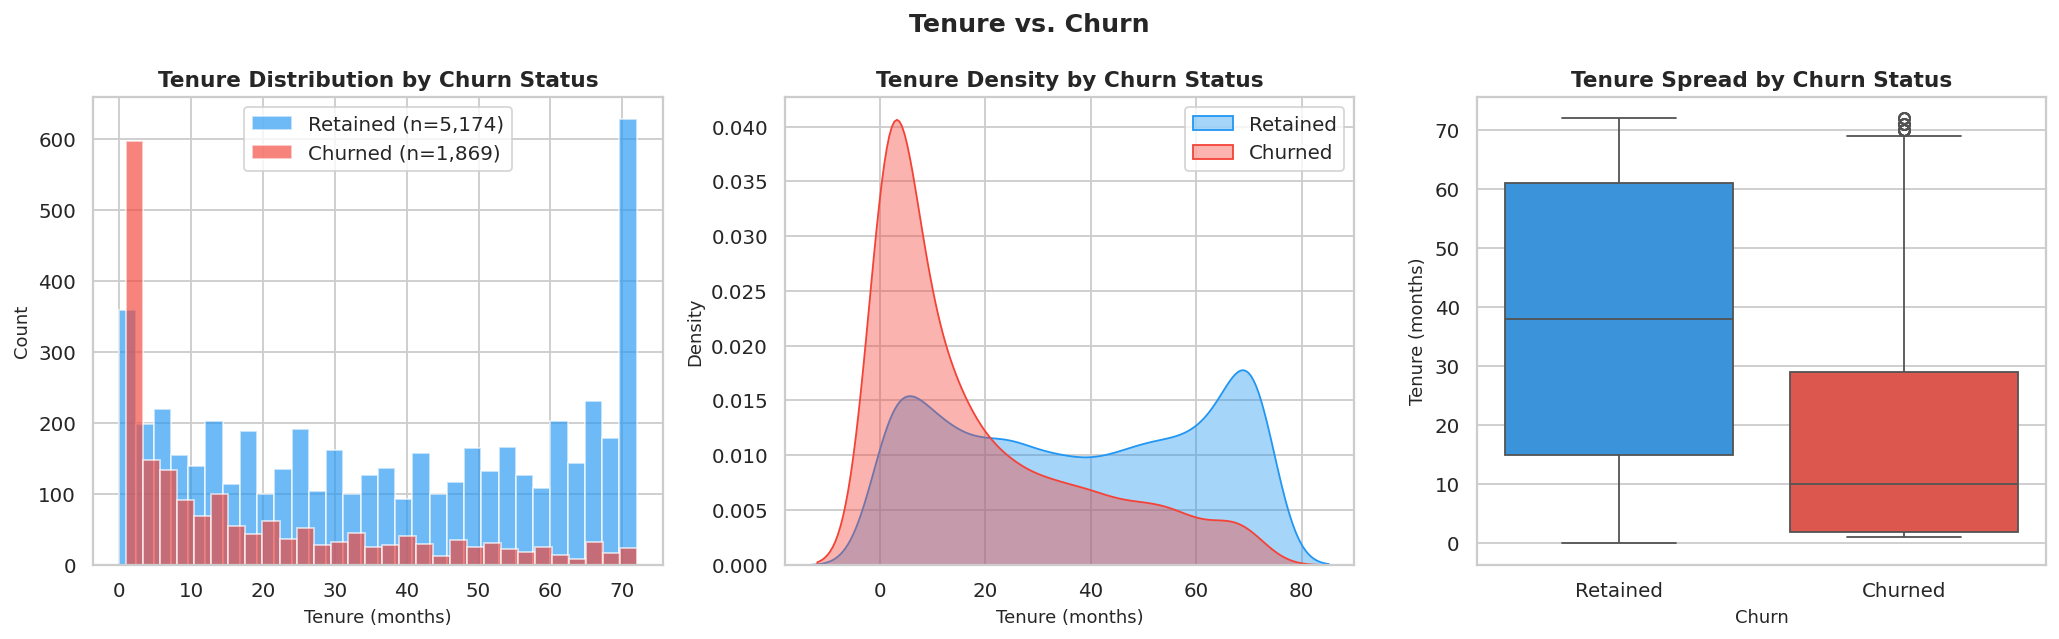

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram: tenure by churn status
for status, colour, label in zip(['No','Yes'], PALETTE, ['Retained','Churned']):
    subset = df[df['Churn'] == status]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.65, color=colour,
                 label=f'{label} (n={len(subset):,})', edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# KDE plot
for status, colour, label in zip(['No','Yes'], PALETTE, ['Retained','Churned']):
    subset = df[df['Churn'] == status]['tenure']
    sns.kdeplot(subset, ax=axes[1], color=colour, fill=True, alpha=0.4, label=label)
axes[1].set_title('Tenure Density by Churn Status')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Box plot
sns.boxplot(data=df, x='Churn', y='tenure', palette=PALETTE,
            order=['No','Yes'], ax=axes[2])
axes[2].set_title('Tenure Spread by Churn Status')
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Tenure (months)')
axes[2].set_xticklabels(['Retained', 'Churned'])

plt.suptitle('Tenure vs. Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


Tenure Group  Churn Rate (%)
     0–12 mo       47.678161
    13–24 mo       28.710938
    25–48 mo       20.388959
    49–72 mo        9.513176


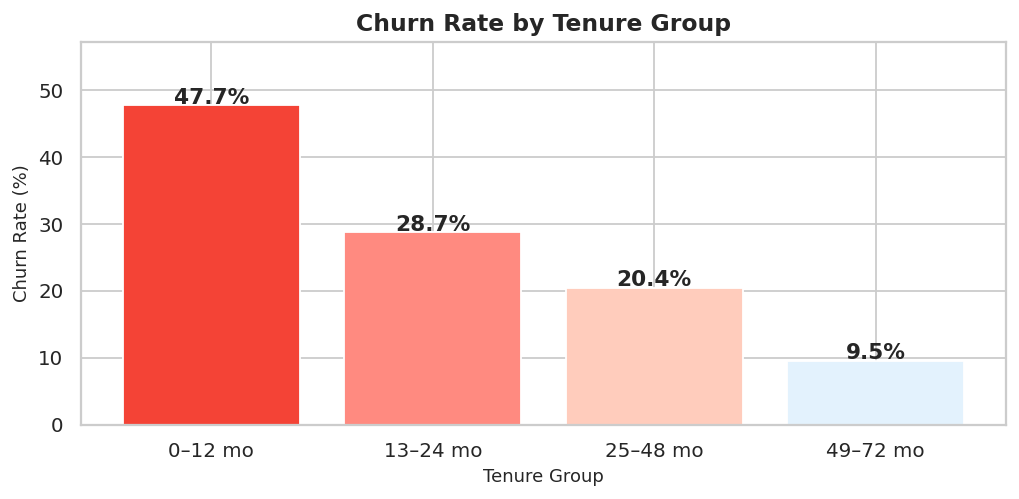

In [8]:
# Tenure buckets for clearer segment view
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 72],
                            labels=['0–12 mo', '13–24 mo', '25–48 mo', '49–72 mo'])

tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
tenure_churn.columns = ['Tenure Group', 'Churn Rate (%)']

print(tenure_churn.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tenure_churn['Tenure Group'], tenure_churn['Churn Rate (%)'],
              color=[CLR_CHURN, '#FF8A80', '#FFCCBC', '#E3F2FD'],
              edgecolor='white', linewidth=1)
for bar, val in zip(bars, tenure_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, tenure_churn['Churn Rate (%)'].max() * 1.2)
plt.tight_layout()
plt.savefig('eda_04_tenure_groups.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['tenure_group'], inplace=True)


## 5. Churn by Contract Type and Payment Method
Contract length and billing method are strong behavioural indicators — customers on
shorter contracts or using electronic payments tend to exhibit higher churn.


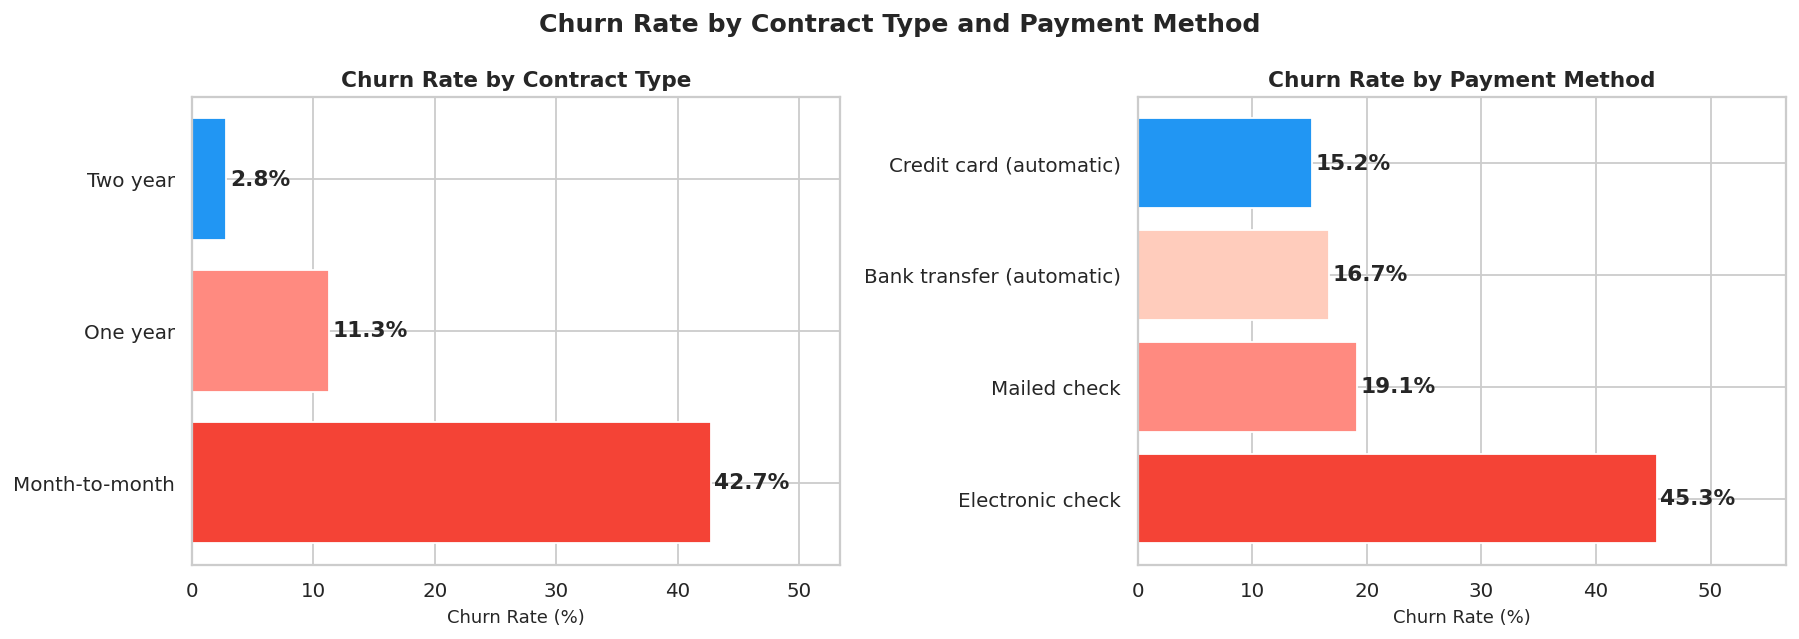

Contract Type Churn Rates:
      Contract  Churn Rate (%)
Month-to-month       42.709677
      One year       11.269518
      Two year        2.831858

Payment Method Churn Rates:
            PaymentMethod  Churn Rate (%)
         Electronic check       45.285412
             Mailed check       19.106700
Bank transfer (automatic)       16.709845
  Credit card (automatic)       15.243101


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']

bars = axes[0].barh(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
                    color=[CLR_CHURN, '#FF8A80', CLR_RETAIN], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_xlabel('Churn Rate (%)')
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[0].set_xlim(0, contract_churn['Churn Rate (%)'].max() * 1.25)

# Payment method
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False).reset_index()
payment_churn.columns = ['PaymentMethod', 'Churn Rate (%)']

colors_pay = [CLR_CHURN, '#FF8A80', '#FFCCBC', CLR_RETAIN]
bars2 = axes[1].barh(payment_churn['PaymentMethod'], payment_churn['Churn Rate (%)'],
                     color=colors_pay, edgecolor='white')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('Churn Rate (%)')
for bar, val in zip(bars2, payment_churn['Churn Rate (%)']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[1].set_xlim(0, payment_churn['Churn Rate (%)'].max() * 1.25)

plt.suptitle('Churn Rate by Contract Type and Payment Method',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_contract_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Contract Type Churn Rates:")
print(contract_churn.to_string(index=False))
print()
print("Payment Method Churn Rates:")
print(payment_churn.to_string(index=False))


## 6. Monthly Charges and Total Charges vs. Churn
Higher monthly charges are often associated with higher churn — customers may feel
the service is not worth the cost. Total charges tend to be lower for churned customers
(consistent with shorter tenures).


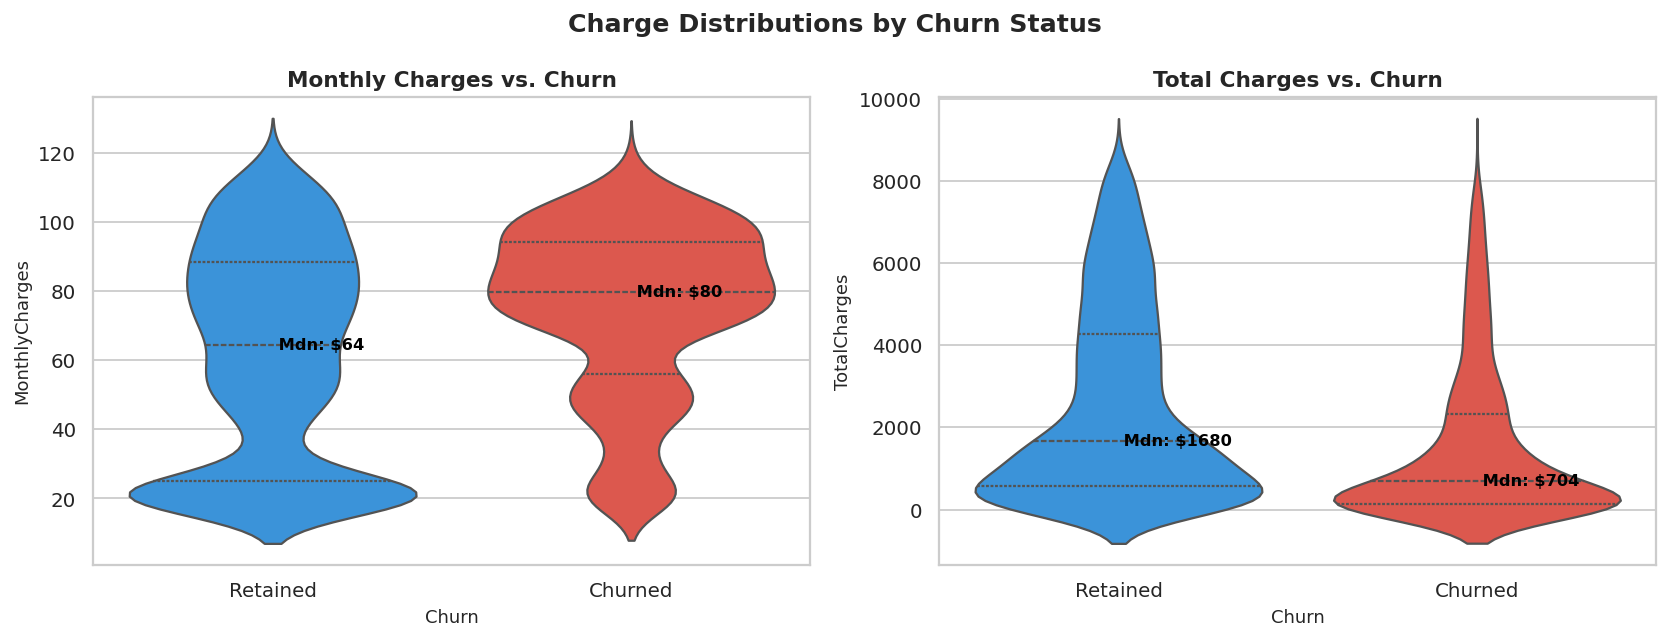

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes,
                           ['MonthlyCharges', 'TotalCharges'],
                           ['Monthly Charges vs. Churn', 'Total Charges vs. Churn']):
    sns.violinplot(data=df, x='Churn', y=col, palette=PALETTE,
                   order=['No','Yes'], ax=ax, inner='quartile')
    ax.set_title(title)
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)
    ax.set_xticklabels(['Retained', 'Churned'])
    # Annotate medians
    for i, status in enumerate(['No','Yes']):
        med = df[df['Churn']==status][col].median()
        ax.text(i, med, f' Mdn: ${med:.0f}', va='center', fontsize=9,
                fontweight='bold', color='black')

plt.suptitle('Charge Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_charges.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Churn by Internet Service Type
Internet service type links directly to monthly charges and often to churn risk —
Fiber optic customers pay more and may be more price-sensitive or face greater competition.


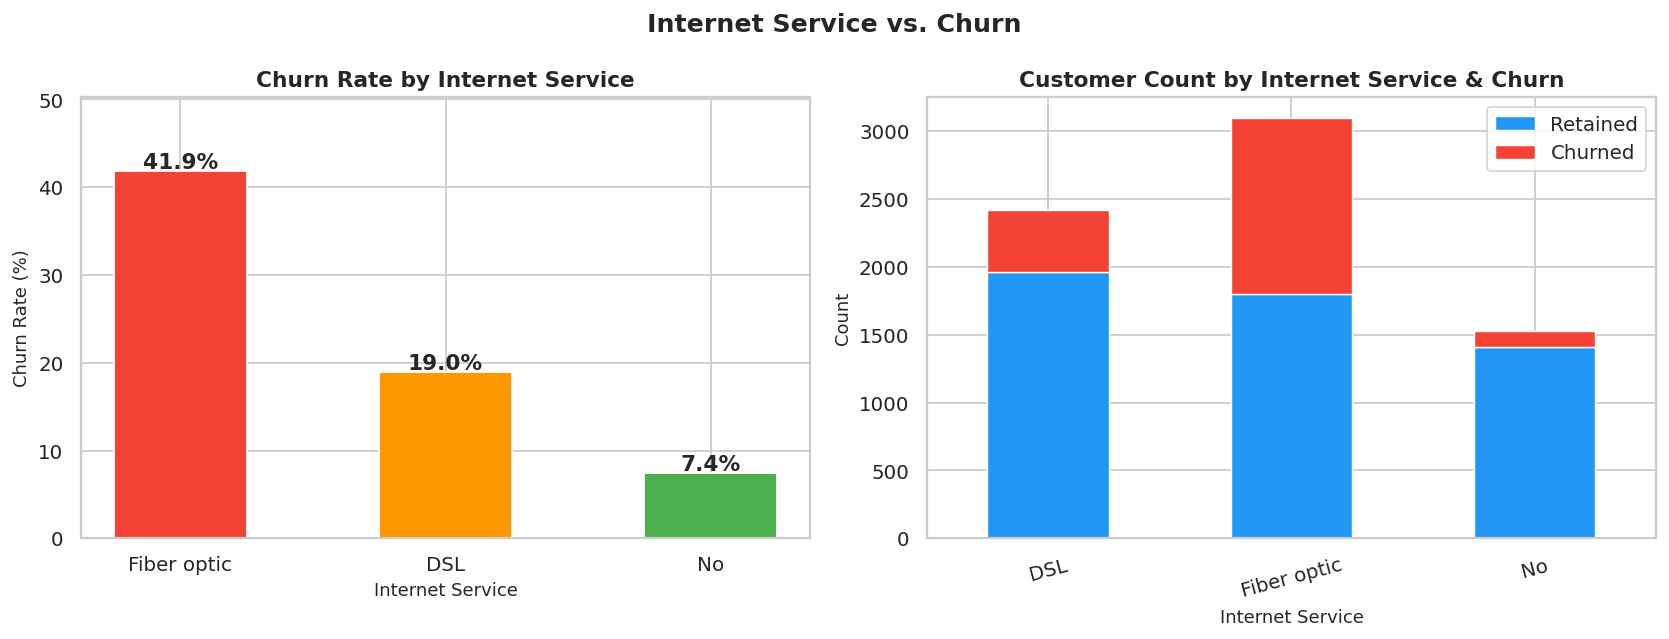

InternetService  Churn Rate (%)
    Fiber optic       41.892765
            DSL       18.959108
             No        7.404980


In [11]:
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False).reset_index()
internet_churn.columns = ['InternetService', 'Churn Rate (%)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate bar
colors_int = ['#F44336', '#FF9800', '#4CAF50']
bars = axes[0].bar(internet_churn['InternetService'], internet_churn['Churn Rate (%)'],
                   color=colors_int, edgecolor='white', width=0.5)
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Internet Service')
for bar, val in zip(bars, internet_churn['Churn Rate (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, internet_churn['Churn Rate (%)'].max() * 1.2)

# Stacked count
ct = pd.crosstab(df['InternetService'], df['Churn'])
ct.plot(kind='bar', stacked=True, ax=axes[1], color=PALETTE,
        edgecolor='white', linewidth=0.8)
axes[1].set_title('Customer Count by Internet Service & Churn')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Internet Service')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Retained', 'Churned'])

plt.suptitle('Internet Service vs. Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_internet_service.png', dpi=150, bbox_inches='tight')
plt.show()
print(internet_churn.to_string(index=False))


## 8. Correlation Heatmap (Processed Features)
Using the encoded dataset from Task 1, we examine how each feature correlates with
the `Churn` target variable and with each other, to spot multicollinearity and key predictors.


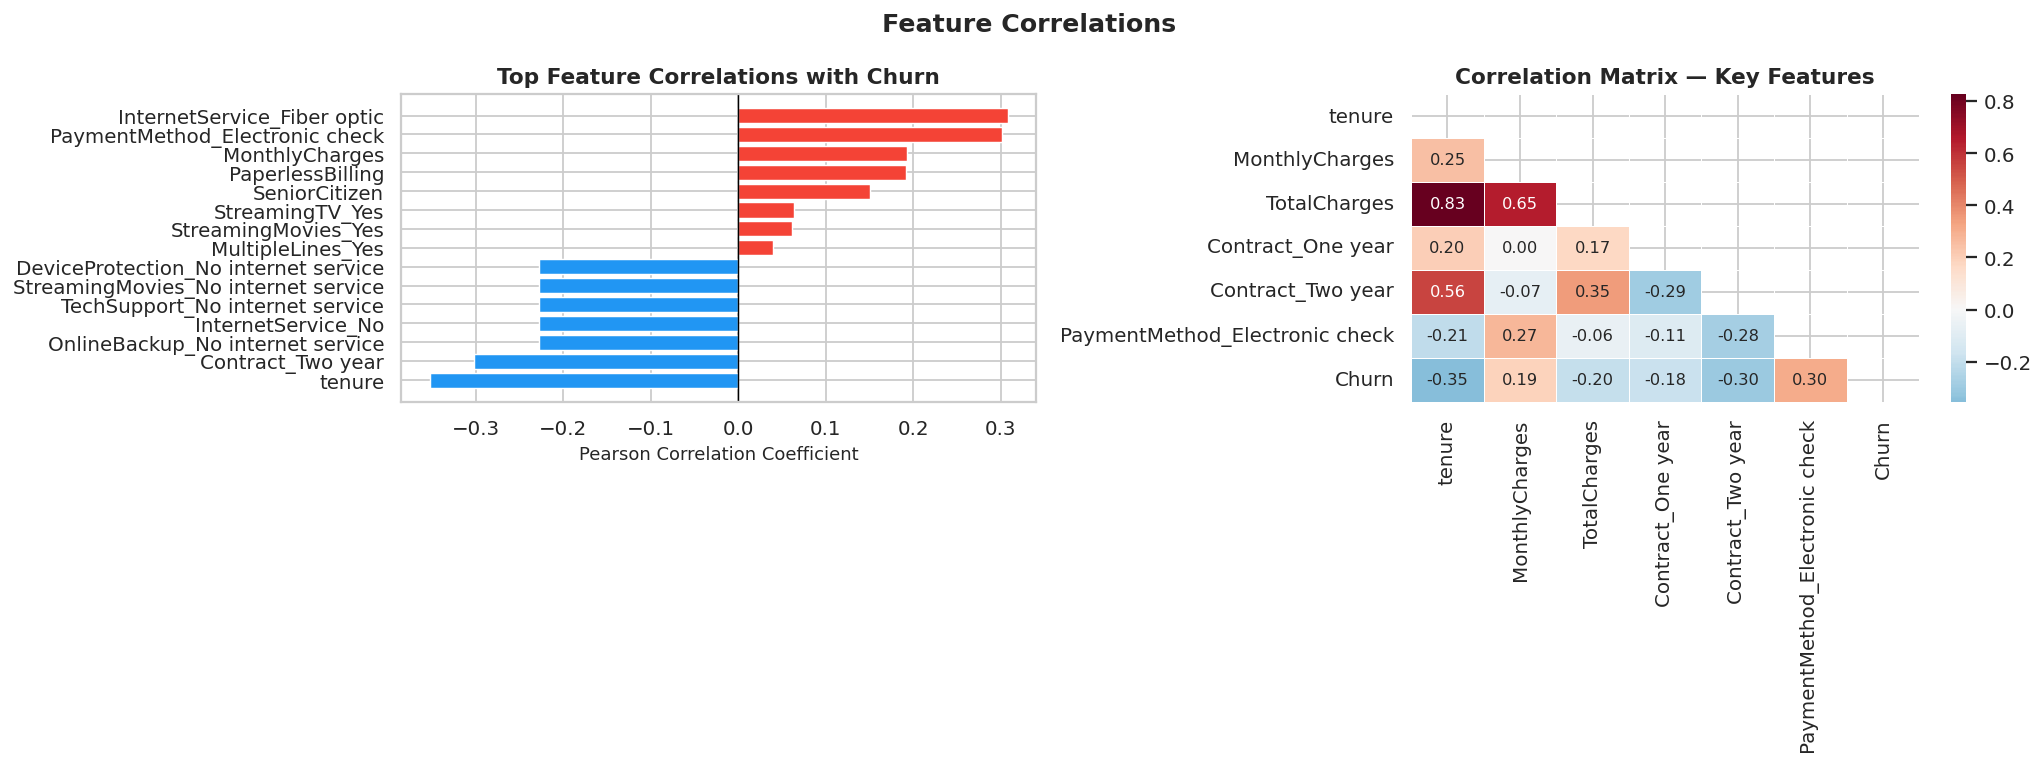

In [12]:
df_enc = pd.read_csv('telco_churn_processed.csv')

# Correlation with Churn — top 15
churn_corr = df_enc.corr()['Churn'].drop('Churn').sort_values()
top_features = pd.concat([churn_corr.head(7), churn_corr.tail(8)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar: correlation with target
colors_corr = [CLR_CHURN if v > 0 else CLR_RETAIN for v in top_features.values]
axes[0].barh(top_features.index, top_features.values, color=colors_corr,
             edgecolor='white', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top Feature Correlations with Churn')
axes[0].set_xlabel('Pearson Correlation Coefficient')

# Heatmap: key numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'Contract_One year', 'Contract_Two year',
            'PaymentMethod_Electronic check', 'Churn']
corr_sub = df_enc[num_cols].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, mask=mask,
            linewidths=0.5, annot_kws={'size': 9})
axes[1].set_title('Correlation Matrix — Key Features')

plt.suptitle('Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
print("=== Top Positive Correlates with Churn (most churn-inducing) ===")
print(churn_corr.tail(8).round(3).to_string())
print()
print("=== Top Negative Correlates with Churn (most retention-linked) ===")
print(churn_corr.head(7).round(3).to_string())


=== Top Positive Correlates with Churn (most churn-inducing) ===
MultipleLines_Yes                 0.040
StreamingMovies_Yes               0.061
StreamingTV_Yes                   0.063
SeniorCitizen                     0.151
PaperlessBilling                  0.192
MonthlyCharges                    0.193
PaymentMethod_Electronic check    0.302
InternetService_Fiber optic       0.308

=== Top Negative Correlates with Churn (most retention-linked) ===
tenure                                 -0.352
Contract_Two year                      -0.302
OnlineBackup_No internet service       -0.228
InternetService_No                     -0.228
TechSupport_No internet service        -0.228
StreamingMovies_No internet service    -0.228
DeviceProtection_No internet service   -0.228


## 9. EDA Summary & Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **26.5% overall churn rate** | Class imbalance — models must handle this carefully |
| 2 | **Gender has minimal effect** | Not a meaningful churn predictor |
| 3 | **Senior citizens churn at ~41%** vs ~24% for non-seniors | Senior-targeted retention needed |
| 4 | **Customers without partners/dependents churn more** | Lifestyle segment is higher risk |
| 5 | **Short-tenure customers (0–12 mo) churn at ~48%** | Onboarding experience is critical |
| 6 | **Month-to-month contracts churn at ~43%** vs ~3% for two-year | Long-term contract migration = key strategy |
| 7 | **Electronic check users churn most (~45%)** | Auto-payment migration could reduce churn |
| 8 | **Fiber optic customers churn at ~42%** | Price-value perception issue at premium tier |
| 9 | **Higher monthly charges correlate positively with churn** | Price sensitivity is real |
| 10 | **Two-year contract is the strongest negative correlate** | Lock-in is the most effective retention lever |

These findings will directly inform both the predictive model (Task 4) and business recommendations.
